In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [2]:
# In[2]:
# ==========================================
# Step 1: Load and Parse Raw JSON Transaction Data
# ==========================================
print("1. Loading and parsing raw JSON transaction data...")

with open('user-wallet-transactions.json', 'r') as f:
    raw_transaction_data = json.load(f)

# Flatten nested JSON structure into tabular format
transaction_df = pd.json_normalize(raw_transaction_data)

1. Loading and parsing raw JSON transaction data...


In [3]:
# In[3]:
# ==========================================
# Step 2: Basic Feature Engineering & Temporal Extraction
# ==========================================
# Ensure transaction amount is float and handle missing values
transaction_df['actionData.amount'] = transaction_df['actionData.amount'].fillna(0).astype(float)

# Convert Unix timestamp to datetime for recency calculation
transaction_df['tx_date'] = pd.to_datetime(transaction_df['timestamp'], unit='s')
dataset_snapshot_date = transaction_df['tx_date'].max()  # Snapshot date (latest transaction date)

# Vectorized mapping for transaction type segmentation
transaction_df['deposit_amount'] = np.where(transaction_df['action'] == 'deposit', transaction_df['actionData.amount'], 0)
transaction_df['borrow_amount']  = np.where(transaction_df['action'] == 'borrow', transaction_df['actionData.amount'], 0)
transaction_df['repay_amount']   = np.where(transaction_df['action'] == 'repay', transaction_df['actionData.amount'], 0)

In [4]:
# In[4]:
# ==========================================
# Step 3: Aggregate Metrics by User Wallet
# ==========================================
# Group by user wallet to compute core financial and behavioral metrics
wallet_features = transaction_df.groupby('userWallet').agg(
    total_deposit=('deposit_amount', 'sum'),
    total_borrow=('borrow_amount', 'sum'),
    total_repay=('repay_amount', 'sum'),
    balance_mean=('actionData.amount', 'mean'),  # For Coefficient of Variation (CV)
    balance_std=('actionData.amount', 'std'),    # For Coefficient of Variation (CV)
    tx_count=('action', 'count'),                # Total transaction frequency
    last_tx_date=('tx_date', 'max')              # For recency calculation
).reset_index()

# Calculate days since last transaction (recency base metric)
wallet_features['days_since_last_tx'] = (dataset_snapshot_date - wallet_features['last_tx_date']).dt.days
wallet_features.drop(columns=['last_tx_date'], inplace=True)

In [5]:
# In[5]:
# ==========================================
# Step 4: Domain-Specific Financial Ratios
# ==========================================
# Health Ratio: Repayment capacity (1 = no borrow activity)
wallet_features['health_ratio'] = np.where(wallet_features['total_borrow'] == 0, 1,
                                           wallet_features['total_repay'] / wallet_features['total_borrow'])

# Leverage Ratio: Borrowing dependency (0 = no deposit activity)
wallet_features['leverage_ratio'] = np.where(wallet_features['total_deposit'] == 0, 0,
                                             wallet_features['total_borrow'] / wallet_features['total_deposit'])

# Fill NaNs from std() for single-transaction users
wallet_features = wallet_features.fillna(0)

In [6]:
# In[6]:
# ==========================================
# Step 5: Strict Data Cleaning (Academic Standard)
# ==========================================
def strict_data_cleaning(input_df):
    """
    Robust data cleaning process compliant with German academic standards.
    Includes Winsorization (outlier handling), missing value reporting, and skewness diagnostics.
    """
    print("\n--- Strict Data Cleaning Diagnostics ---")

    # 1. Winsorization: Clip extreme outliers (99th percentile) for whale account handling
    cols_to_winsorize = ['total_deposit', 'total_borrow', 'total_repay', 'tx_count']
    for col in cols_to_winsorize:
        upper_quantile = input_df[col].quantile(0.99)
        input_df[col] = input_df[col].clip(upper=upper_quantile)

    # 2. Missing Data Report
    missing_data_ratio = input_df.isnull().mean()
    print(f"Missing Data Ratio:\n{missing_data_ratio[missing_data_ratio > 0]}\n(Empty if no missing data.)")

    # 3. Skewness Check (Normality validation; ideal range: -1 to 1)
    print(f"\nSkewness Report (Ideal range: -1 to 1):\n{input_df.skew(numeric_only=True)}")

    return input_df

# Execute strict cleaning
cleaned_features = strict_data_cleaning(wallet_features)


--- Strict Data Cleaning Diagnostics ---
Missing Data Ratio:
Series([], dtype: float64)
(Empty if no missing data.)

Skewness Report (Ideal range: -1 to 1):
total_deposit          7.233058
total_borrow           7.689731
total_repay            7.410925
balance_mean          34.881450
balance_std           29.961559
tx_count               3.847631
days_since_last_tx     0.503357
health_ratio          -1.047295
leverage_ratio        41.798445
dtype: float64



✅ Data collection completed. 3497 unique wallets extracted. Saved as 01_cleaned_features.csv


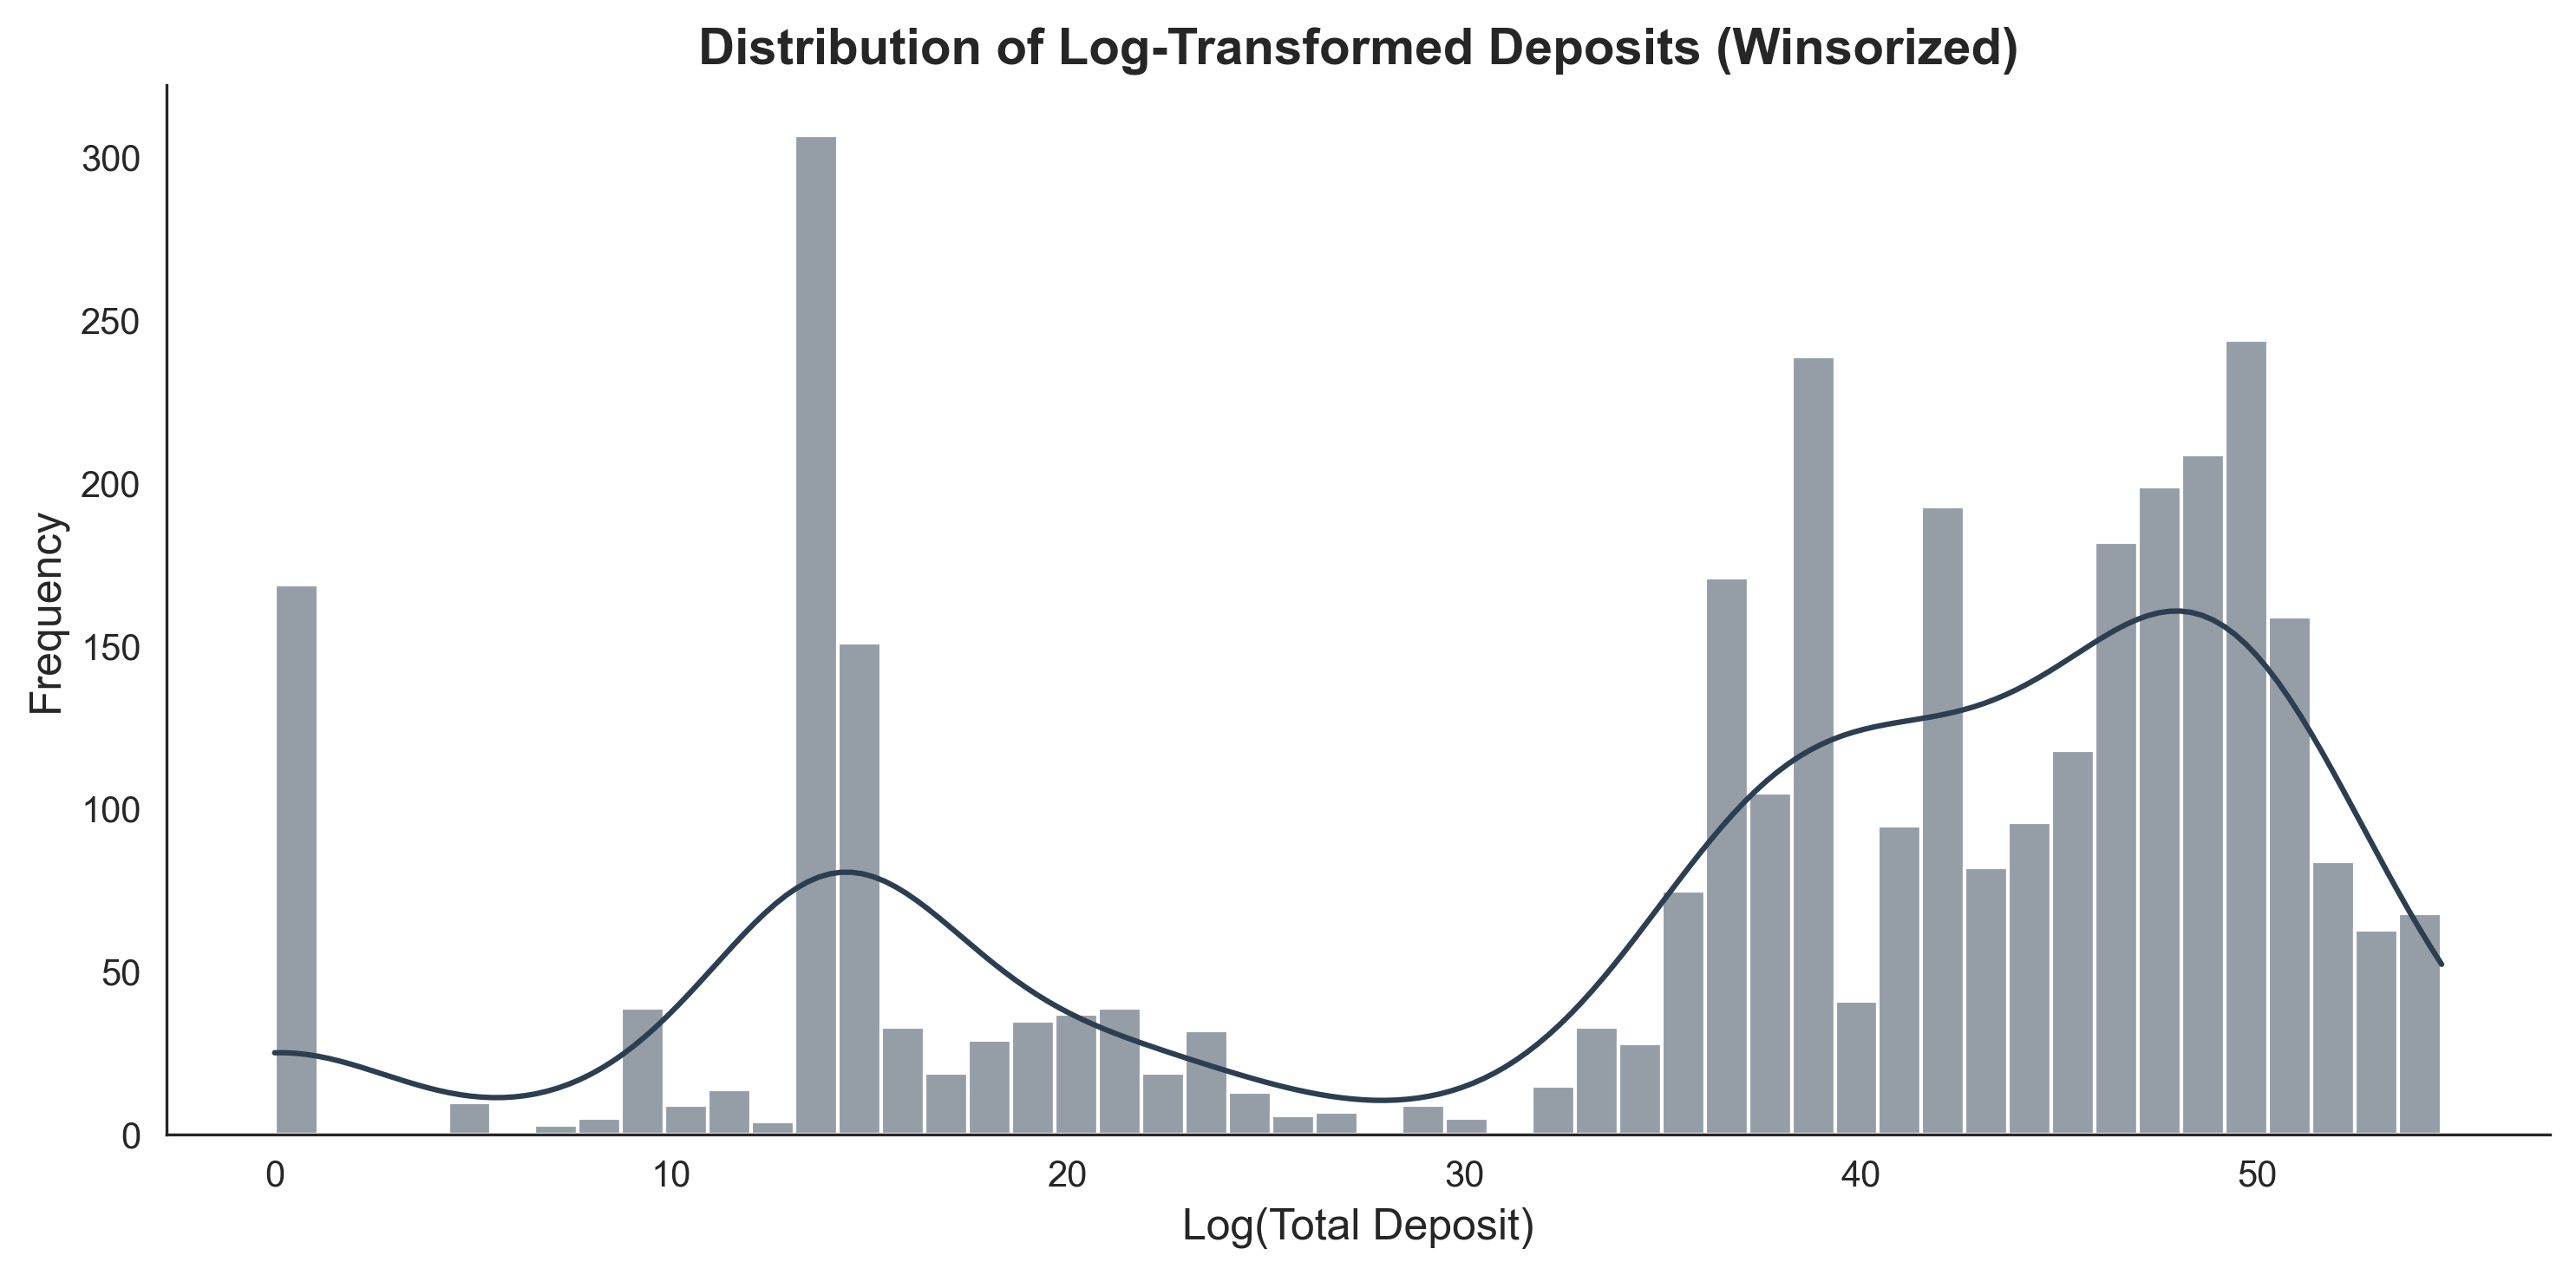

In [7]:
# In[7]:
# ==========================================
# Step 6: Save Cleaned Features & Basic EDA Visualization
# ==========================================
# Save cleaned base table for downstream modeling
cleaned_features.to_csv("01_cleaned_features.csv", index=False)
print(f"\n✅ Data collection completed. {len(cleaned_features)} unique wallets extracted. Saved as 01_cleaned_features.csv")

# Academic-style EDA: Log-transformed deposit distribution (Winsorized)
sns.set_style("white")
plt.figure(figsize=(10, 5), dpi=300)

sns.histplot(np.log1p(cleaned_features['total_deposit']), bins=50, kde=True, color='#2c3e50')
plt.title('Distribution of Log-Transformed Deposits (Winsorized)', fontsize=14, fontweight='bold')
plt.xlabel('Log(Total Deposit)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Despine for academic aesthetics (remove top/right borders)
sns.despine()
plt.tight_layout()
plt.savefig("deposit_distribution_academic.png")
plt.show()